# Лекция 11. Атаки на приватность: membership inference, model inversion

Демонстрация: membership inference attack на основе confidence score, простая model inversion атака.

## 1. Обучение переобученной модели (для наглядной демонстрации membership inference)

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
torch.manual_seed(0)
np.random.seed(0)

import torchvision
import torchvision.transforms as T

transform = T.Compose([T.ToTensor()])
train_ds = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_ds = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_ds, batch_size=1, shuffle=True)

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.fc = nn.Linear(32*7*7,10)
    def forward(self,x):
        x = F.relu(self.conv1(x)); x = F.max_pool2d(x,2)
        x = F.relu(self.conv2(x)); x = F.max_pool2d(x,2)
        x = x.view(x.size(0),-1)
        return self.fc(x)

model = SimpleCNN()
opt = torch.optim.Adam(model.parameters(), lr=1e-3)
for i,(xb,yb) in enumerate(train_loader):
    opt.zero_grad(); loss = F.cross_entropy(model(xb), yb); loss.backward(); opt.step()
    if i>=300: break
print("Базовая модель обучена, loss:", loss.item())

overfit_model = SimpleCNN()
opt_of = torch.optim.Adam(overfit_model.parameters(), lr=1e-3)
small_train = torch.utils.data.Subset(train_ds, range(500))
small_loader = torch.utils.data.DataLoader(small_train, batch_size=32, shuffle=True)
for epoch in range(30):
    for xb, yb in small_loader:
        opt_of.zero_grad(); loss = F.cross_entropy(overfit_model(xb), yb); loss.backward(); opt_of.step()
print("Переобученная модель на малой выборке (500 примеров), финальный loss:", loss.item())


Базовая модель обучена, loss: 0.11312925815582275
Переобученная модель на малой выборке (500 примеров), финальный loss: 0.01478480827063322


## 2. Membership Inference Attack: confidence score как признак

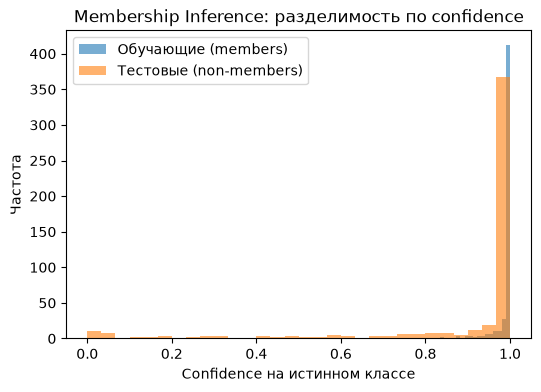

Точность простого MIA по порогу confidence=0.99: 60.80%


In [2]:

def get_confidences(model, dataset, n=500):
    confs = []
    for i in range(n):
        x, y = dataset[i]
        out = F.softmax(model(x.unsqueeze(0)), dim=1)
        confs.append(out[0,y].item())
    return np.array(confs)

member_confs = get_confidences(overfit_model, small_train, n=500)
nonmember_confs = get_confidences(overfit_model, test_ds, n=500)

plt.figure(figsize=(6,4))
plt.hist(member_confs, bins=30, alpha=0.6, label='Обучающие (members)')
plt.hist(nonmember_confs, bins=30, alpha=0.6, label='Тестовые (non-members)')
plt.xlabel("Confidence на истинном классе"); plt.ylabel("Частота")
plt.legend(); plt.title("Membership Inference: разделимость по confidence")
plt.savefig('output/notebooks/lec11_mia.png', dpi=120)
plt.show()

threshold = 0.99
mia_acc = ((member_confs>threshold).sum() + (nonmember_confs<=threshold).sum()) / (len(member_confs)+len(nonmember_confs))
print(f"Точность простого MIA по порогу confidence={threshold}: {mia_acc:.2%}")


## 3. Простая Model Inversion атака (восстановление 'типичного' входа для класса)

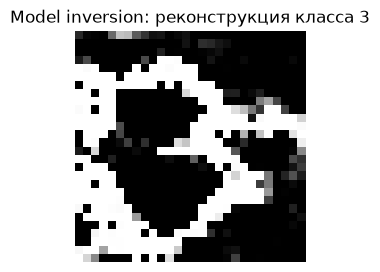

Изображение отражает 'усреднённые' признаки класса, выученные моделью, без доступа к реальным данным


In [3]:

target_class = 3
x_recon = torch.rand(1,1,28,28, requires_grad=True)
opt_inv = torch.optim.Adam([x_recon], lr=0.1)

for step in range(300):
    opt_inv.zero_grad()
    out = overfit_model(torch.clamp(x_recon,0,1))
    loss = -out[0, target_class] + 0.01*x_recon.pow(2).sum()
    loss.backward(); opt_inv.step()

plt.figure(figsize=(3,3))
plt.imshow(torch.clamp(x_recon,0,1)[0,0].detach().numpy(), cmap='gray')
plt.title(f"Model inversion: реконструкция класса {target_class}")
plt.axis('off')
plt.savefig('output/notebooks/lec11_inversion.png', dpi=120)
plt.show()
print("Изображение отражает 'усреднённые' признаки класса, выученные моделью, без доступа к реальным данным")
